# Classical confidence intervals in one call

`conf_int` turns a bootstrap run into a confidence interval for a statistic of one
series. You pass the series, the statistic, and a method spec; it runs the bootstrap
and reads back the interval you asked for. This tour builds percentile, basic, and
studentized intervals on a dependent AR(1) series, shows why BCa is refused for block
methods (and why that refusal protects you), and finishes with per-series intervals
over a ragged panel.

The four interval families, shortest to say:

- `percentile` and `basic` are first-order correct and need only the replicate
  distribution.
- `studentized` is second-order correct for smooth statistics when its per-replicate
  standard error is dependence-aware, which `conf_int` arranges with a block jackknife.
- `bca` corrects for bias and skewness, but its acceleration is defined under
  independent sampling, so it is offered for the `IID` spec only.

Coverage here is approximate or asymptotic under temporal dependence, not finite-sample
distribution-free, the same honest ceiling as the rest of the uq layer.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## A dependent series

We use an AR(1) series with positive autocorrelation and a true mean of zero. The
dependence is what makes the interval choice matter: a naive i.i.d. interval would
understate the variance of the sample mean, so it would be too narrow.

In [2]:
import numpy as np


def ar1(phi, n, seed):
    """AR(1) started at its first innovation; true mean 0 for zero drift."""
    rng = np.random.default_rng(seed)
    e = rng.standard_normal(n)
    x = np.empty(n)
    x[0] = e[0]
    for t in range(1, n):
        x[t] = phi * x[t - 1] + e[t]
    return x


x = ar1(0.5, 200, seed=0)
print(f"series length {x.size}, sample mean {x.mean():.3f}")

series length 200, sample mean 0.030


## Percentile, basic, and studentized, one call each

Each interval is a single `conf_int` call. We use a `MovingBlock` method so the
resampling respects the AR(1) dependence, a small `n_bootstraps` to keep the tutorial
quick, and the built-in `"mean"` statistic. The studentized path estimates a
dependence-aware standard error with a block jackknife on its own; you do not have to
supply one.

In [3]:
from tsbootstrap import MovingBlock, conf_int

ALPHA = 0.1  # 90% intervals
B = 399
method = MovingBlock(block_length="auto")

intervals = {}
point = None
for kind in ("percentile", "basic", "studentized"):
    lower, upper, point = conf_int(
        x, "mean", method=method, kind=kind, alpha=ALPHA, n_bootstraps=B, random_state=0
    )
    intervals[kind] = (float(lower), float(upper))

print(f"point estimate (sample mean): {float(point):.3f}")

point estimate (sample mean): 0.030


In [4]:
import pandas as pd

summary = pd.DataFrame(
    {
        kind: {
            "lower": lo,
            "upper": hi,
            "width": hi - lo,
            "covers 0": "yes" if lo <= 0.0 <= hi else "no",
        }
        for kind, (lo, hi) in intervals.items()
    }
).T
summary.round(4)

,lower,upper,width,covers 0
percentile,-0.190865,0.301442,0.492307,yes
basic,-0.241749,0.250558,0.492307,yes
studentized,-0.24268,0.283117,0.525797,yes


All three intervals bracket the true mean of zero. The percentile and basic bands have
the same width because basic is the percentile band reflected through the point
estimate. The studentized band is a little wider: it accounts for the extra uncertainty
in the per-replicate standard error, which is the cost of its second-order correctness
under dependence.

## A picture of the three intervals

The same three intervals drawn as error bars around the point estimate, with the true
mean marked.

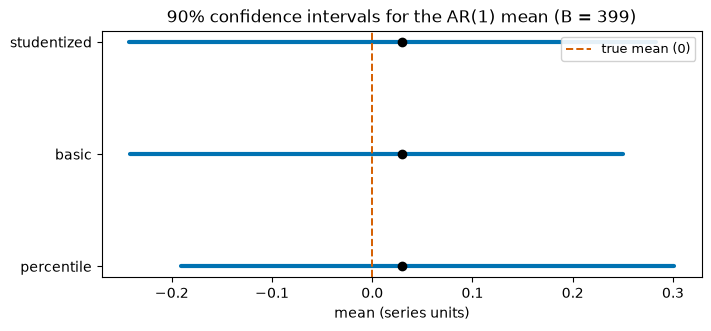

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.2), layout="constrained")
names = list(intervals)
for i, (lo, hi) in enumerate(intervals.values()):
    ax.plot([lo, hi], [i, i], color="#0072B2", lw=3, solid_capstyle="round")
    ax.plot(float(point), i, marker="o", color="black", zorder=5)
ax.axvline(0.0, color="#D55E00", ls="--", lw=1.4, label="true mean (0)")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel("mean (series units)")
ax.set_title(f"90% confidence intervals for the AR(1) mean (B = {B})")
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
plt.show()

## Why BCa is refused for block methods

BCa corrects the percentile interval for median bias and skewness, which makes it a
strong default on i.i.d. data. Its acceleration constant, though, is a delete-one
jackknife estimate that is only defined under independent sampling (Efron 1987). There
is no valid drop-in version of that constant for dependent data, so asking for
`kind="bca"` with a block method raises a typed error rather than quietly returning an
interval built on an invalid constant. The refusal is doing its job: it protects the
statistical validity of the result and points you at the studentized interval, which is
the second-order-correct route for dependent data.

In [6]:
from tsbootstrap.errors import MethodConfigError

try:
    conf_int(x, "mean", method=MovingBlock(block_length="auto"), kind="bca", alpha=ALPHA)
except MethodConfigError as exc:
    print("MethodConfigError raised, as intended:\n")
    print(exc)

MethodConfigError raised, as intended:

[TSB_UNSUPPORTED_MODEL_FEATURE] BCa intervals are only supported with the IID method spec; got MovingBlock. The acceleration constant is a delete-one jackknife estimate defined under independent observations (Efron 1987); for dependent data the second-order-correct route is the studentized interval (Gotze and Kunsch 1996). Hint: Use kind='studentized' or kind='percentile' with this method, or method=IID() when the observations are exchangeable.


## BCa on i.i.d. data, where it belongs

With the `IID` spec the acceleration is well defined, so BCa runs and returns a
skew-corrected interval. On a right-skewed statistic this is where BCa earns its keep
over the plain percentile band: both bands bracket the true mean of 1, but the BCa band
shifts to correct the skew.

In [7]:
from tsbootstrap import IID

skewed = np.random.default_rng(1).exponential(1.0, size=60)  # true mean 1, right-skewed
lo_pct, hi_pct, _ = conf_int(
    skewed, "mean", method=IID(), kind="percentile", alpha=ALPHA, n_bootstraps=999, random_state=1
)
lo_bca, hi_bca, _ = conf_int(
    skewed, "mean", method=IID(), kind="bca", alpha=ALPHA, n_bootstraps=999, random_state=1
)
print(f"sample mean: {skewed.mean():.3f}")
print(f"percentile: [{lo_pct:.3f}, {hi_pct:.3f}]")
print(f"BCa:        [{lo_bca:.3f}, {hi_bca:.3f}]  (shifted right to correct the skew)")

sample mean: 1.116
percentile: [0.851, 1.432]
BCa:        [0.865, 1.473]  (shifted right to correct the skew)


## Intervals over a ragged panel

`conf_int_panel` computes a per-series interval for a whole collection of series in one
pass, even when they have different lengths. It builds on the panel bootstrap, so it
takes the observation-resampling methods only. The studentized panel path needs an
explicit block length: a replicate reducer sees one series at a time without its
identity, so a per-series automatic block length cannot be resolved honestly. We pass
`se_block_length` to supply it.

In [8]:
from tsbootstrap import conf_int_panel

panel = [ar1(0.4, n, seed=100 + i) for i, n in enumerate((120, 180, 90))]

lower, upper, point = conf_int_panel(
    panel,
    "mean",
    method=MovingBlock(block_length=10),
    kind="studentized",
    alpha=ALPHA,
    se_block_length=10,
    n_bootstraps=299,
    random_state=0,
)

panel_table = pd.DataFrame(
    {"length": [s.size for s in panel], "point": point, "lower": lower, "upper": upper}
)
panel_table.index.name = "series"
panel_table.round(4)

,length,point,lower,upper
series,,,,
0,120,0.1328,-0.0270,0.3817
1,180,-0.1221,-0.2695,0.0518
2,90,-0.0530,-0.3899,0.2961


## When to use which

- Reach for `percentile` or `basic` as the distribution-free default; they assume the
  least and work with every method.
- Use `studentized` when you want second-order accuracy under dependence and can afford
  the block-jackknife standard error. It is the recommended route for time series.
- Use `bca` for i.i.d. data with a skewed statistic, where its bias and skew correction
  buys real accuracy. `conf_int` refuses it for dependent methods rather than return a
  constant that is not valid there.
- Use `conf_int_panel` when you have many series and want an interval for each in one
  pass.

Whatever the family, the coverage claim stays approximate or asymptotic under temporal
dependence, so read these as calibrated guidance rather than exact guarantees.